<a href="https://colab.research.google.com/github/Aaricis/Hung-yi-Lee-ML2022/blob/main/HW3/HW03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW3 Image Classification
## We strongly recommend that you run with Kaggle for this homework


## Sample Baseline
Score: 0.63047
Private score: 0.61416 (n_epochs = 10)

直接跑一边Sample Code提交结果，如果没到Sample Baseline，就多train几个epoch。从训练数据来看，大约训练5个epoch就可以到Sample Baseline。

## Medium Baseline
Score: 0.77788
Private score: 0.76056

根据助教提示，进行Data Augmentation，然后训练更多epoch。实作中从易到难尝试了三种Data Augmentation。


由于`torchvision.transforms.v2`比`torchvision.transforms`有更丰富的功能且速度更快，因此使用`torchvision.transforms.v2`实现Data Augmentation。

ref: https://pytorch.org/vision/0.21/transforms.html
>

```python
import torchvision.transforms.v2 as transforms
```

1. 使用基础API


```python
train_tfm = transforms.Compose([
    transforms.RandomResizedCrop(128),    # 随机裁剪 & 缩放到 224x224
    transforms.RandomHorizontalFlip(p=0.5),  # 50% 概率水平翻转
    transforms.RandomRotation(degrees=15),  # 旋转 ±15°
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),  # 颜色抖动
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # 10% 随机平移
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),  # 随机锐化
    transforms.RandomPosterize(bits=4, p=0.5),  # 颜色减少
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5), # 随机透视变换
    transforms.ToImage(),  # 转换为 Tensor
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # 归一化
])
```
2. Auto-Augmentation

我们并不知道当前数据适合使用哪些Data Augmentation方法，因此借助Auto-Augmentation为数据集自动搜索合适的Augmentation方法。实作中使用`TrivialAugmentWide()`,其他方法也可以选用。

ref: https://pytorch.org/vision/0.21/transforms.html#auto-augmentation

```python
train_tfm = transforms.Compose([
    transforms.RandomResizedCrop(128, antialias=True),
    transforms.RandomHorizontalFlip(0.5),
    transforms.TrivialAugmentWide(),
    transforms.PILToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ])
```

3. Auto-Augmentation + CutMix & MixUp Transform

在`TrivialAugmentWide()`基础上增加CutMix & MixUp Transform方法。
ref:https://pytorch.org/vision/main/auto_examples/transforms/plot_cutmix_mixup.html#sphx-glr-auto-examples-transforms-plot-cutmix-mixup-py

- 定义`def collate_fn(batch)`函数；

```python
from torch.utils.data import default_collate

NUM_CLASSES = 11
cutmix = transforms.CutMix(num_classes= NUM_CLASSES)
mixup = transforms.MixUp(num_classes= NUM_CLASSES)
cutmix_or_mixup = transforms.RandomChoice([cutmix, mixup])

def collate_fn(batch):
    return cutmix_or_mixup(*default_collate(batch))
```

- `train_loader`新增`collate_fn=collate_fn`参数；

```python
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True, drop_last=True, collate_fn=collate_fn) # CutMix and MixUp Transform

```
### **总结**
- Auto-Augmentation + CutMix & MixUp Transform速度最快，效果最佳。如👇图所示，Private Score和Public Score较接近，模型没有发生过拟合，泛化性好。总共训练370个Epoch即可超过Medium Baseline(Private Score : 0.71361, Public Score : 0.73207)
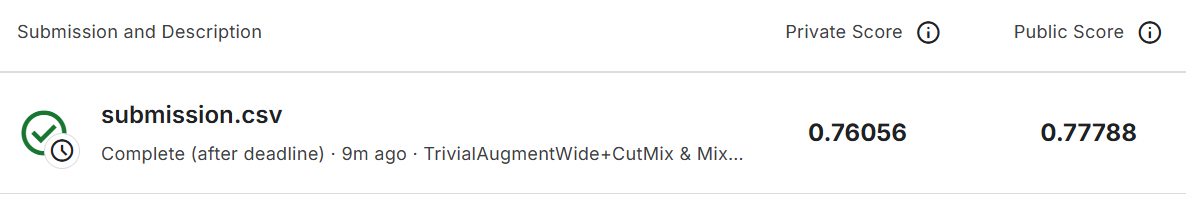

- 基础API和Auto-Augmentation方法需要训练约1000个Epoch才能超过Medium Bseline，且模型发生过拟合，Score也较低。
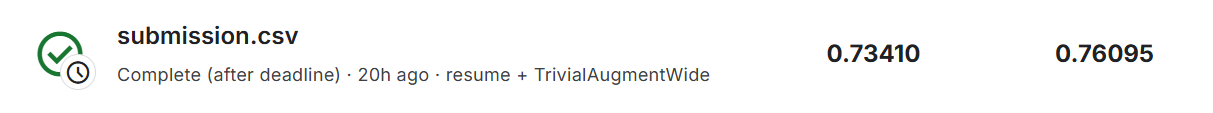


## Strong Baseline
Score: 0.87948
Private score: 0.87323

加载Medium Baseline中Auto-Augmentation + CutMix & MixUp Transform方法预训练的模型，然后在‘Testing and generate prediction CSV’阶段使用Test Time Augmentation(TTA)方法的version_2版本生成预测结果，就超过了Strong Baseline，并且很接近Boss Baseline，令人十分意外❗

**模型预测阶段使用好的预测方法也可以极大的提高测试集精度，不一定要训练更强更复杂的模型。**

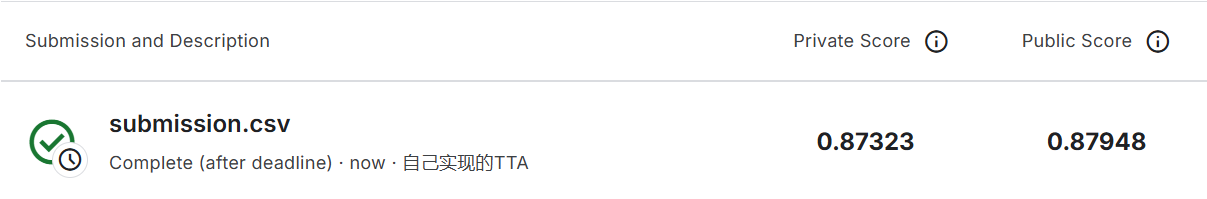

## Boss Baseline
Score: 0.88745
Private score: 0.87878

- 在Medium基础上使用ResNet50模型+dropout+batchnorm训练约500个epoch。


```python
class ResNet50(nn.Module):
    def __init__(self, num_classes=11):
        super(ResNet50, self).__init__()
        
        # 加载 ResNet50 模型（去掉最后的 fc 层）
        resnet = resnet50(weights=None)  # 使用 weights=ResNet50_Weights.IMAGENET1K_V1 加载预训练权重
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])  # 去掉 fc 层
        
        # 获取原始 fc 层的输入特征数
        num_features = resnet.fc.in_features
        
        # 定义新的 fc 层
        self.fc = nn.Sequential(
            nn.Linear(num_features, 1024),
            nn.BatchNorm1d(1024),  # Batch Normalization
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),  # Batch Normalization
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout

            nn.Linear(512, num_classes)  # 输出层
        )

    def forward(self, x):
        # 提取特征
        out = self.cnn(x)
        
        # 展平特征
        out = torch.flatten(out, 1)  # 使用 torch.flatten 代替 view
        
        # 分类
        out = self.fc(out)
        return out
```

- 挑选三份最好的结果作ensemble，实作中选择投票法。








# Get Data
Notes: if the links are dead, you can download the data directly from Kaggle and upload it to the workspace, or you can use the Kaggle API to directly download the data into colab.


In [1]:
! wget https://www.dropbox.com/s/6l2vcvxl54b0b6w/food11.zip

--2025-03-04 08:12:28--  https://www.dropbox.com/s/6l2vcvxl54b0b6w/food11.zip
Resolving www.dropbox.com (www.dropbox.com)... 162.125.81.18, 2620:100:6035:18::a27d:5512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.81.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/hjgabr8fbuvuzjvtp77b1/food11.zip?rlkey=nsgokn3hjmer9ss6p1v9aag98 [following]
--2025-03-04 08:12:29--  https://www.dropbox.com/scl/fi/hjgabr8fbuvuzjvtp77b1/food11.zip?rlkey=nsgokn3hjmer9ss6p1v9aag98
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc77af2dd3b2bf9bc33591acff4a.dl.dropboxusercontent.com/cd/0/inline/ClMIGSBCGzW4y81LDqsCG7e9nR4tHfVW-MvYRuEdUt2hHfQseMQTAbXRqVMWxcY-qoXMjKe46iTB6c0pJZwS5F0oxgkeJzPclgsZxzv8k5sr6rgkQ_PC85Xp4JkIqGeJqVPrVKfijSxJ2LbnbiujaVbM/file# [following]
--2025-03-04 08:12:29--  https://uc77af2dd3b2bf9bc33591acff4a.dl.dropboxusercontent.com/cd/0/inline/ClMI

In [2]:
! unzip food11.zip

流式输出内容被截断，只能显示最后 5000 行内容。
  inflating: food11/training/8_806.jpg  
  inflating: food11/training/8_807.jpg  
  inflating: food11/training/8_808.jpg  
  inflating: food11/training/8_809.jpg  
  inflating: food11/training/8_81.jpg  
  inflating: food11/training/8_810.jpg  
  inflating: food11/training/8_811.jpg  
  inflating: food11/training/8_812.jpg  
  inflating: food11/training/8_813.jpg  
  inflating: food11/training/8_814.jpg  
  inflating: food11/training/8_815.jpg  
  inflating: food11/training/8_816.jpg  
  inflating: food11/training/8_817.jpg  
  inflating: food11/training/8_818.jpg  
  inflating: food11/training/8_819.jpg  
  inflating: food11/training/8_82.jpg  
  inflating: food11/training/8_820.jpg  
  inflating: food11/training/8_821.jpg  
  inflating: food11/training/8_822.jpg  
  inflating: food11/training/8_823.jpg  
  inflating: food11/training/8_824.jpg  
  inflating: food11/training/8_825.jpg  
  inflating: food11/training/8_826.jpg  
  inflating: food11/training/8_8

# Training

In [5]:
_exp_name = "boss_224"

In [4]:
# Import necessary packages.
import numpy as np
import pandas as pd
import torch
import os
import torch.nn as nn
# import torchvision.transforms as transforms
import torchvision.transforms.v2 as transforms
from PIL import Image
# "ConcatDataset" and "Subset" are possibly useful when doing semi-supervised learning.
from torch.utils.data import ConcatDataset, DataLoader, Subset, Dataset
from torchvision.datasets import DatasetFolder, VisionDataset
# Pretrained model
from torchvision.models import resnet50

# This is for the progress bar.
from tqdm.auto import tqdm
import random

# Cross Validation
from sklearn.model_selection import KFold

# Learning Rate
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

In [6]:
myseed = 6666  # set a random seed for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

## **Transforms**
Torchvision provides lots of useful utilities for image preprocessing, data wrapping as well as data augmentation.

Please refer to PyTorch official website for details about different transforms.

In [7]:
# Normally, We don't need augmentations in testing and validation.
# All we need here is to resize the PIL image and transform it into Tensor.
test_tfm = transforms.Compose([
    transforms.Resize((224, 224)), # 128
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# However, it is also possible to use augmentation in the testing phase.
# You may use train_tfm to produce a variety of images and then test using ensemble methods
# train_tfm = transforms.Compose([
#     # Resize the image into a fixed shape (height = width = 128)
#     transforms.Resize((128, 128)),
#     # You may add some transforms here.
#     # ToTensor() should be the last one of the transforms.
#     transforms.ToTensor(),
# ])

train_tfm = transforms.Compose([
    transforms.RandomResizedCrop(224, antialias=True), # 128
    transforms.RandomHorizontalFlip(0.5),
    transforms.TrivialAugmentWide(),
    transforms.PILToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ])

/usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


### CutMix & MixUp Transform

In [8]:
from torch.utils.data import default_collate

NUM_CLASSES = 11
cutmix = transforms.CutMix(num_classes= NUM_CLASSES)
mixup = transforms.MixUp(num_classes= NUM_CLASSES)
cutmix_or_mixup = transforms.RandomChoice([cutmix, mixup])

def collate_fn(batch):
    return cutmix_or_mixup(*default_collate(batch))

## **Datasets**
The data is labelled by the name, so we load images and label while calling '__getitem__'

In [9]:
class FoodDataset(Dataset):

    def __init__(self,path,tfm=test_tfm,files = None):
        super(FoodDataset).__init__()
        self.path = path
        self.files = sorted([os.path.join(path,x) for x in os.listdir(path) if x.endswith(".jpg")])
        if files != None:
            self.files = files
        print(f"One {path} sample",self.files[0])
        self.transform = tfm

    def __len__(self):
        return len(self.files)

    def __getitem__(self,idx):
        fname = self.files[idx]
        im = Image.open(fname)
        im = self.transform(im)
        #im = self.data[idx]
        try:
            label = int(fname.split("/")[-1].split("_")[0])
        except:
            label = -1 # test has no label
        return im,label



## Model

### CNN

In [9]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        # torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        # torch.nn.MaxPool2d(kernel_size, stride, padding)
        # input 維度 [3, 128, 128]
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),  # [64, 128, 128]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0),      # [64, 64, 64]

            nn.Conv2d(64, 128, 3, 1, 1), # [128, 64, 64]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0),      # [128, 32, 32]

            nn.Conv2d(128, 256, 3, 1, 1), # [256, 32, 32]
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0),      # [256, 16, 16]

            nn.Conv2d(256, 512, 3, 1, 1), # [512, 16, 16]
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0),       # [512, 8, 8]

            nn.Conv2d(512, 512, 3, 1, 1), # [512, 8, 8]
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0),       # [512, 4, 4]
        )
        self.fc = nn.Sequential(
            nn.Linear(512*4*4, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 11)
        )

    # def forward(self, x):
    #     out = self.cnn(x)
    #     out = out.view(out.size()[0], -1)
    #     return self.fc(out)

    def forward(self, x):
      batch_size = x.size(0)
      out = self.cnn(x)
      out = out.view(batch_size, -1)
      return self.fc(out)




### ResNet50

In [10]:
class ResNet50(nn.Module):
    def __init__(self, num_classes=11):
        super(ResNet50, self).__init__()

        # 加载 ResNet50 模型（去掉最后的 fc 层）
        resnet = resnet50(weights=None)  # 使用 weights=ResNet50_Weights.IMAGENET1K_V1 加载预训练权重
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])  # 去掉 fc 层

        # 获取原始 fc 层的输入特征数
        num_features = resnet.fc.in_features

        # 定义新的 fc 层
        self.fc = nn.Sequential(
            nn.Linear(num_features, 1024),
            nn.BatchNorm1d(1024),  # Batch Normalization
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),  # Batch Normalization
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout

            nn.Linear(512, num_classes)  # 输出层
        )

    def forward(self, x):
        # 提取特征
        out = self.cnn(x)

        # 展平特征
        out = torch.flatten(out, 1)  # 使用 torch.flatten 代替 view

        # 分类
        out = self.fc(out)
        return out

## Dataloader

In [11]:
batch_size = 64
_dataset_dir = "./food11"
# Construct datasets.
# The argument "loader" tells how torchvision reads the data.
train_set = FoodDataset(os.path.join(_dataset_dir,"training"), tfm=train_tfm)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True, collate_fn=collate_fn) # CutMix and MixUp Transform
valid_set = FoodDataset(os.path.join(_dataset_dir,"validation"), tfm=test_tfm)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

One ./food11/training sample ./food11/training/0_0.jpg
One ./food11/validation sample ./food11/validation/0_0.jpg


## Start Training

### 普通训练

In [12]:
# "cuda" only when GPUs are available.
device = "cuda" if torch.cuda.is_available() else "cpu"

# The number of training epochs and patience.
n_epochs = 200
patience = 20 # If no improvement in 'patience' epochs, early stop

# Initialize a model, and put it on the device specified.
# model = Classifier().to(device)
model = ResNet50().to(device)

RESUME = False
if RESUME:
    model.load_state_dict(torch.load('/content/boss_best.ckpt', map_location=device), strict=False)

# For the classification task, we use cross-entropy as the measurement of performance.
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Initialize optimizer, you may fine-tune some hyperparameters such as learning rate on your own.
# optimizer = torch.optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-5)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Define the CosineAnnealingWarmRestarts scheduler
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=2, eta_min=0.0001)

# Initialize trackers, these are not parameters and should not be changed
stale = 0
best_acc = 0

for epoch in range(n_epochs):

    # ---------- Training ----------
    # Make sure the model is in train mode before training.
    model.train()

    # These are used to record information in training.
    train_loss = []
    train_accs = []

    for batch in tqdm(train_loader):

        # A batch consists of image data and corresponding labels.
        imgs, labels = batch
        #imgs = imgs.half()

        # Forward the data. (Make sure data and model are on the same device.)
        logits = model(imgs.to(device))

        # Calculate the cross-entropy loss.
        # We don't need to apply softmax before computing cross-entropy as it is done automatically.
        loss = criterion(logits, labels.to(device))

        # Gradients stored in the parameters in the previous step should be cleared out first.
        optimizer.zero_grad()

        # Compute the gradients for parameters.
        loss.backward()

        # Clip the gradient norms for stable training.
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)

        # Update the parameters with computed gradients.
        optimizer.step()

        # Update the learning rate
        scheduler.step()

        # Compute the accuracy for current batch.
        # print(logits.shape, labels.shape)
        # acc = (logits.argmax(dim=-1) == labels.to(device)).float().mean()
        _, predicted = torch.max(logits, 1)
        _, true_labels = torch.max(labels, 1)  # Get the true labels from the one-hot encoded labels
        correct = (predicted == true_labels.to(device)).float().sum().item()
        acc = correct / labels.size(0)

        # Record the loss and accuracy.
        train_loss.append(loss.item())
        train_accs.append(acc)

    train_loss = sum(train_loss) / len(train_loss)
    train_acc = sum(train_accs) / len(train_accs)

    # Print the information.
    print(f"[ Train | {epoch + 1:03d}/{n_epochs:03d} ] loss = {train_loss:.5f}, acc = {train_acc:.5f}")

    # ---------- Validation ----------
    # Make sure the model is in eval mode so that some modules like dropout are disabled and work normally.
    model.eval()

    # These are used to record information in validation.
    valid_loss = []
    valid_accs = []

    # Iterate the validation set by batches.
    for batch in tqdm(valid_loader):

        # A batch consists of image data and corresponding labels.
        imgs, labels = batch
        #imgs = imgs.half()

        # We don't need gradient in validation.
        # Using torch.no_grad() accelerates the forward process.
        with torch.no_grad():
            logits = model(imgs.to(device))

        # We can still compute the loss (but not the gradient).
        loss = criterion(logits, labels.to(device))

        # Compute the accuracy for current batch.
        acc = (logits.argmax(dim=-1) == labels.to(device)).float().mean()

        # Record the loss and accuracy.
        valid_loss.append(loss.item())
        valid_accs.append(acc)
        #break

    # The average loss and accuracy for entire validation set is the average of the recorded values.
    valid_loss = sum(valid_loss) / len(valid_loss)
    valid_acc = sum(valid_accs) / len(valid_accs)

    # Print the information.
    print(f"[ Valid | {epoch + 1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")


    # update logs
    if valid_acc > best_acc:
        with open(f"./{_exp_name}_log.txt","a"):
            print(f"[ Valid | {epoch + 1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f} -> best")
    else:
        with open(f"./{_exp_name}_log.txt","a"):
            print(f"[ Valid | {epoch + 1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")


    # save models
    if valid_acc > best_acc:
        print(f"Best model found at epoch {epoch}, saving model")
        torch.save(model.state_dict(), f"{_exp_name}_best.ckpt") # only save best to prevent output memory exceed error
        best_acc = valid_acc
        stale = 0
    else:
        stale += 1
        if stale > patience:
            print(f"No improvment {patience} consecutive epochs, early stopping")
            break

  0%|          | 0/155 [00:00<?, ?it/s]

KeyboardInterrupt: 

### K-Fold Cross Validation

In [ ]:
batch_size = 64
_dataset_dir = "./food11"

# 合并训练集和验证集
train_dataset = FoodDataset(os.path.join(_dataset_dir,"training"), tfm=train_tfm)
val_dataset = FoodDataset(os.path.join(_dataset_dir,"validation"), tfm=train_tfm)

merged_dataset = ConcatDataset([train_dataset, val_dataset])

# 设置K值
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# "cuda" only when GPUs are available.
device = "cuda" if torch.cuda.is_available() else "cpu"
# The number of training epochs and patience.
n_epochs = 200
patience = 20 # If no improvement in 'patience' epochs, early stop

# 交叉验证结果
fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(merged_dataset)):
    print(f"Fold {fold + 1}/{K}")

    # 训练集 & 验证集
    train_subset = Subset(merged_dataset, train_idx)
    val_subset = Subset(merged_dataset, val_idx)

    # 数据加载器
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True, collate_fn=collate_fn) # CutMix and MixUp Transform
    valid_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

    # Initialize a model, and put it on the device specified.
    # model = Classifier().to(device)
    model = ResNet50().to(device)

    # For the classification task, we use cross-entropy as the measurement of performance.
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Initialize optimizer, you may fine-tune some hyperparameters such as learning rate on your own.
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-5)

    stale = 0
    best_acc = 0

    for epoch in range(n_epochs):
      # ---------- Training ----------
      # Make sure the model is in train mode before training.
      model.train()

      # These are used to record information in training.
      train_loss = []
      train_accs = []

      for batch in tqdm(train_loader):
        imgs, labels = batch
        logits = model(imgs.to(device))
        loss = criterion(logits, labels.to(device))
        optimizer.zero_grad()
        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)
        optimizer.step()

        # Compute the accuracy for current batch.
        _, predicted = torch.max(logits, 1)
        _, true_labels = torch.max(labels, 1)  # Get the true labels from the one-hot encoded labels
        correct = (predicted == true_labels.to(device)).float().sum().item()
        acc = correct / labels.size(0)

        # Record the loss and accuracy.
        train_loss.append(loss.item())
        train_accs.append(acc)

      train_loss = sum(train_loss) / len(train_loss)
      train_acc = sum(train_accs) / len(train_accs)

      # Print the information.
      print(f"[ Train | {epoch + 1:03d}/{n_epochs:03d} ] loss = {train_loss:.5f}, acc = {train_acc:.5f}")

      # ---------- Validation ----------
      model.eval()

      valid_loss = []
      valid_accs = []

      for batch in tqdm(valid_loader):
        imgs, labels = batch

        with torch.no_grad():
          logits = model(imgs.to(device))

        loss = criterion(logits, labels.to(device))
        acc = (logits.argmax(dim=-1) == labels.to(device)).float().mean()

        valid_loss.append(loss.item())
        valid_accs.append(acc)

      valid_loss = sum(valid_loss) / len(valid_loss)
      valid_acc = sum(valid_accs) / len(valid_accs)

      print(f"[ Valid | {epoch + 1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")

      # update logs
      if valid_acc > best_acc:
          with open(f"./{_exp_name}_log.txt","a"):
              print(f"[ Valid | {epoch + 1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f} -> best")
      else:
          with open(f"./{_exp_name}_log.txt","a"):
              print(f"[ Valid | {epoch + 1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")


      # save models
      if valid_acc > best_acc:
          print(f"Best model found at epoch {epoch}, saving model")
          torch.save(model.state_dict(), f"{_exp_name}_{fold}_best.ckpt") # only save best to prevent output memory exceed error
          best_acc = valid_acc
          stale = 0
      else:
          stale += 1
          if stale > patience:
              print(f"No improvment {patience} consecutive epochs, early stopping")
              break

      fold_results.append(best_acc)


One ./food11/training sample ./food11/training/0_0.jpg
One ./food11/validation sample ./food11/validation/0_0.jpg
Fold 1/5


  0%|          | 0/167 [00:00<?, ?it/s]

[ Train | 001/001 ] loss = 2.27279, acc = 0.18812


  0%|          | 0/42 [00:00<?, ?it/s]

[ Valid | 001/001 ] loss = 2.18501, acc = 0.23111
[ Valid | 001/001 ] loss = 2.18501, acc = 0.23111 -> best
Best model found at epoch 0, saving model
Fold 2/5


  0%|          | 0/167 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Testing and generate prediction CSV

In [ ]:
test_set = FoodDataset(os.path.join(_dataset_dir,"test"), tfm=test_tfm)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

One ./food11/test sample ./food11/test/0001.jpg


In [ ]:
# model_best = Classifier().to(device)
# model_best.load_state_dict(torch.load(f"{_exp_name}_best.ckpt"))

model_best = ResNet50().to(device)
# model_best.load_state_dict(torch.load('/content/medium_0_best.ckpt', map_location=device))
model_best.load_state_dict(torch.load(f"{_exp_name}_best.ckpt"))
model_best.eval()
prediction = []
with torch.no_grad():
    for data,_ in test_loader:
        test_pred = model_best(data.to(device))
        test_label = np.argmax(test_pred.cpu().data.numpy(), axis=1)
        prediction += test_label.squeeze().tolist()

<ipython-input-27-dbd03c7f39ca>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best.load_state_dict(torch.load(f"{_exp_name}_best.ckpt"))


In [ ]:
# For K-Fold Cross Validation

# 加载最佳模型
best_fold = fold_results.index(max(fold_results))
model_best = Classifier().to(device)
model_best.load_state_dict(torch.load(f"{_exp_name}_{best_fold}_best.ckpt"))
model_best.eval()
prediction = []
with torch.no_grad():
    for data,_ in test_loader:
        test_pred = model_best(data.to(device))
        test_label = np.argmax(test_pred.cpu().data.numpy(), axis=1)
        prediction += test_label.squeeze().tolist()


<ipython-input-20-1ce50b31cad8>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best.load_state_dict(torch.load(f"{_exp_name}_{best_fold}_best.ckpt"))


In [ ]:
#create test csv
def pad4(i):
    return "0"*(4-len(str(i)))+str(i)
df = pd.DataFrame()
df["Id"] = [pad4(i) for i in range(1,len(test_set)+1)]
df["Category"] = prediction
df.to_csv("submission.csv",index = False)

## Test Time Augmentation(TTA)
ref:

https://www.cnblogs.com/dctwan/p/17428922.html

https://github.com/qubvel/ttach


### version_1（弃用）
- 直接使用ttach包实现。

- 因为ttach包支持的Transform方式有限，TTA变换与训练时不匹配，最后结果反而变差。

In [ ]:
!pip install ttach

In [ ]:
import ttach as tta

device = "cuda" if torch.cuda.is_available() else "cpu"

model_best = Classifier().to(device)
model_best.load_state_dict(torch.load('/content/medium_best.ckpt'))
model_best.eval()

# Define the transformations
transforms = tta.Compose([
    tta.HorizontalFlip(),
    tta.VerticalFlip(),
    tta.Rotate90(angles=[0, 90, 180, 270]),
    tta.Resize(sizes=[(128, 128)], interpolation="bilinear"),
    tta.Add(values=[-0.1, 0, 0.1]),
    tta.Multiply(factors=[0.9, 1, 1.1]),
    tta.FiveCrops(crop_height=128, crop_width=128),
])

# Wrap the model with TTA
tta_model = tta.ClassificationTTAWrapper(model_best, transforms, merge_mode='max')

# Perform predictions with TTA
prediction = []
with torch.no_grad():
    for data,_ in tqdm(test_loader):
        # Apply TTA and get predictions
        outputs = tta_model(data.to(device))
        _, predicted = torch.max(outputs, 1)
        prediction.extend(predicted.cpu().numpy())

# Process the predictions as needed
print(prediction)


<ipython-input-32-3547345b0e51>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best.load_state_dict(torch.load('/content/medium_best.ckpt'))


  0%|          | 0/53 [00:00<?, ?it/s]

[1, 6, 0, 1, 6, 6, 6, 1, 1, 6, 1, 0, 4, 1, 1, 6, 6, 9, 1, 1, 6, 1, 4, 3, 2, 2, 0, 1, 1, 4, 6, 5, 1, 1, 6, 6, 1, 6, 4, 0, 5, 1, 0, 1, 6, 0, 0, 6, 6, 0, 1, 1, 1, 1, 0, 7, 6, 5, 1, 1, 1, 1, 6, 1, 0, 0, 1, 6, 0, 1, 1, 0, 4, 1, 0, 0, 1, 0, 7, 6, 0, 6, 0, 2, 1, 5, 0, 1, 4, 1, 0, 1, 0, 6, 6, 6, 5, 4, 1, 1, 1, 1, 1, 1, 5, 1, 1, 0, 5, 6, 2, 1, 0, 0, 0, 1, 6, 1, 1, 0, 10, 5, 6, 3, 6, 1, 1, 6, 1, 1, 5, 2, 5, 1, 6, 0, 4, 1, 6, 1, 2, 7, 3, 0, 4, 1, 4, 0, 4, 1, 2, 1, 5, 1, 6, 1, 1, 0, 4, 1, 1, 0, 1, 6, 0, 1, 1, 0, 1, 1, 1, 1, 6, 0, 0, 6, 1, 7, 1, 2, 1, 6, 1, 0, 7, 0, 1, 1, 1, 3, 2, 6, 2, 1, 0, 1, 1, 4, 6, 1, 6, 2, 0, 0, 0, 1, 3, 0, 6, 1, 1, 5, 0, 1, 0, 6, 1, 1, 6, 6, 0, 1, 1, 5, 1, 6, 2, 10, 1, 1, 1, 4, 2, 4, 4, 0, 0, 6, 0, 5, 1, 1, 1, 4, 0, 6, 0, 1, 1, 1, 0, 0, 6, 6, 4, 5, 5, 0, 1, 1, 5, 8, 1, 1, 6, 6, 0, 6, 0, 1, 2, 1, 7, 1, 1, 5, 0, 1, 1, 1, 4, 0, 0, 1, 0, 2, 0, 4, 4, 2, 4, 1, 0, 2, 1, 1, 1, 0, 1, 7, 6, 6, 0, 1, 5, 1, 1, 6, 2, 5, 3, 5, 1, 0, 1, 4, 1, 1, 6, 1, 4, 6, 0, 0, 6, 1, 0, 1, 5, 1, 0, 1, 7

In [ ]:
print(len(prediction))

3347


### version_2
参考助教提示，自己实现TTA。

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# model_best = Classifier().to(device)
model_best = ResNet50().to(device)

# model_best.load_state_dict(torch.load('/content/medium_0_best.ckpt', map_location=device))
model_best.load_state_dict(torch.load(f"{_exp_name}_best.ckpt"))
model_best.eval()


# 5个使用train_tfm测试集
test_loaders = []
for i in range(5):
    test_set_i = FoodDataset(os.path.join(_dataset_dir, 'test'), tfm=train_tfm)
    test_loader_i = DataLoader(test_set_i, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loaders.append(test_loader_i)

# preds存放在6个测试集(1+5)上的测试结果矩阵，每个矩阵是(3347,11)
preds = [[], [], [], [], [], []]
prediction = []
with torch.no_grad():
    # 用test_tfm的测试集
    for data, _ in test_loader:
        test_preds = model_best(data.to(device)).cpu().data.numpy()
        preds[0].extend(test_preds)
    # 5个用train_tfm的测试集
    for i, loader in enumerate(test_loaders):
        for data, _ in loader:
            test_preds = model_best(data.to(device)).cpu().data.numpy()
            preds[i+1].extend(test_preds)


# preds_np = np.array(preds, dtype=object)
preds_np = np.stack(preds, axis=0)  # 变成 shape=(6, 3347, 11)
print('preds_np shape: {}'.format(preds_np.shape))
# 对6个测试结果加权求和
bb = 0.5 * preds_np[0] + 0.1 * preds_np[1] + 0.1 * preds_np[2] + 0.1 * preds_np[3] + 0.1 * preds_np[4] + 0.1 * preds_np[5]
print('bb shape: {}'.format(bb.shape))
prediction = np.argmax(bb, axis=1)

<ipython-input-29-9a3d2cc601ec>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best.load_state_dict(torch.load(f"{_exp_name}_best.ckpt"))


One ./food11/test sample ./food11/test/0001.jpg
One ./food11/test sample ./food11/test/0001.jpg
One ./food11/test sample ./food11/test/0001.jpg
One ./food11/test sample ./food11/test/0001.jpg
One ./food11/test sample ./food11/test/0001.jpg
preds_np shape: (6, 3347, 11)
bb shape: (3347, 11)


In [ ]:
#create test csv
def pad4(i):
    return "0"*(4-len(str(i)))+str(i)
df = pd.DataFrame()
df["Id"] = [pad4(i) for i in range(1,len(test_set)+1)]
df["Category"] = prediction
df.to_csv("submission.csv",index = False)

## Ensemble
Voting(投票法)：选择票数最多的类别作为最终预测。

**注意**：投票法至少提供>=3份结果进行ensemble，不然会一直平票。

In [4]:
import pandas as pd
from collections import Counter

# 读取多个 CSV 文件
csv_files = ["/content/submission_1.csv", "/content/submission_2.csv", "/content/submission.csv"]

# 读取所有预测结果
preds_list = [pd.read_csv(f).set_index("Id")["Category"] for f in csv_files]

# 创建最终预测 DataFrame
final_preds = preds_list[0].copy()

# 遍历所有 ID 进行投票
for idx in final_preds.index:
    votes = [preds[idx] for preds in preds_list]  # 获取所有模型的预测类别
    final_preds[idx] = Counter(votes).most_common(1)[0][0]  # 选择出现最多的类别

# 保存融合后的结果
final_preds.to_csv("ensemble_voting.csv", index=True, header=["Category"])
print("投票融合完成，结果保存在 ensemble_voting.csv")


投票融合完成，结果保存在 ensemble_voting.csv


# Q1. Augmentation Implementation
## Implement augmentation by finishing train_tfm in the code with image size of your choice.
## Directly copy the following block and paste it on GradeScope after you finish the code
### Your train_tfm must be capable of producing 5+ different results when given an identical image multiple times.
### Your  train_tfm in the report can be different from train_tfm in your training code.


In [ ]:
train_tfm = transforms.Compose([
    # Resize the image into a fixed shape (height = width = 128)
    transforms.Resize((128, 128)),
    # You need to add some transforms here.
    transforms.ToTensor(),
])

# Q2. Residual Implementation
![](https://i.imgur.com/GYsq1Ap.png)
## Directly copy the following block and paste it on GradeScope after you finish the code


In [ ]:
from torch import nn
class Residual_Network(nn.Module):
    def __init__(self):
        super(Residual_Network, self).__init__()

        self.cnn_layer1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
        )

        self.cnn_layer2 = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
        )

        self.cnn_layer3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
        )

        self.cnn_layer4 = nn.Sequential(
            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
        )
        self.cnn_layer5 = nn.Sequential(
            nn.Conv2d(128, 256, 3, 2, 1),
            nn.BatchNorm2d(256),
        )
        self.cnn_layer6 = nn.Sequential(
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
        )
        self.fc_layer = nn.Sequential(
            nn.Linear(256* 32* 32, 256),
            nn.ReLU(),
            nn.Linear(256, 11)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        # input (x): [batch_size, 3, 128, 128]
        # output: [batch_size, 11]

        # Extract features by convolutional layers.
        x1 = self.cnn_layer1(x)

        x1 = self.relu(x1)

        x2 = self.cnn_layer2(x1)

        x2 = self.relu(x2)

        x3 = self.cnn_layer3(x2)

        x3 = self.relu(x3)

        x4 = self.cnn_layer4(x3)

        x4 = self.relu(x4)

        x5 = self.cnn_layer5(x4)

        x5 = self.relu(x5)

        x6 = self.cnn_layer6(x5)

        x6 = self.relu(x6)

        # The extracted feature map must be flatten before going to fully-connected layers.
        xout = x6.flatten(1)

        # The features are transformed by fully-connected layers to obtain the final logits.
        xout = self.fc_layer(xout)
        return xout